<h1>Chapter 7-Cluster Analysis using the Iris Dataset<h1>

<p>In the Iris dataset, the elbow occurs at k = 3 in Figure 7.9. This matches the known number of species. However, because K-means uses random starting points, different runs may occasionally suggest slightly different results.</p>

<p>Another way to evaluate clustering is the silhouette score, which measures how well-separated the clusters are. Values range from –1 to 1. Higher values indicate better-defined clusters.</p>

<p>For the Iris dataset:<br />
•	k = 2:  0.5818<br />
•	k = 3:  0.4799<br />
•	k = 4:  0.3850</p>

<p>We run the Python program three times and change k to either 2, 3, or 4.</p>

<p>The silhouette score suggests that two clusters are most clearly separated. This makes sense because one species, Iris setosa, is very distinct from the other two. However, we know that the dataset actually contains three species. Therefore, even though two clusters provide stronger separation, choosing three clusters better reflects the true structure of the data.</p>


First five observations:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


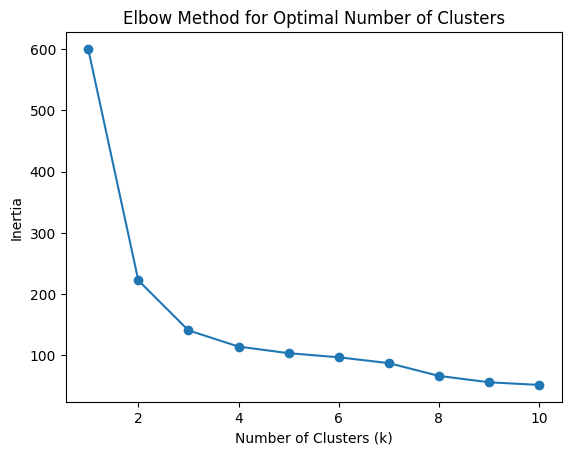


Silhouette Score for 3 clusters: 0.4799

First few rows with cluster assignments:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


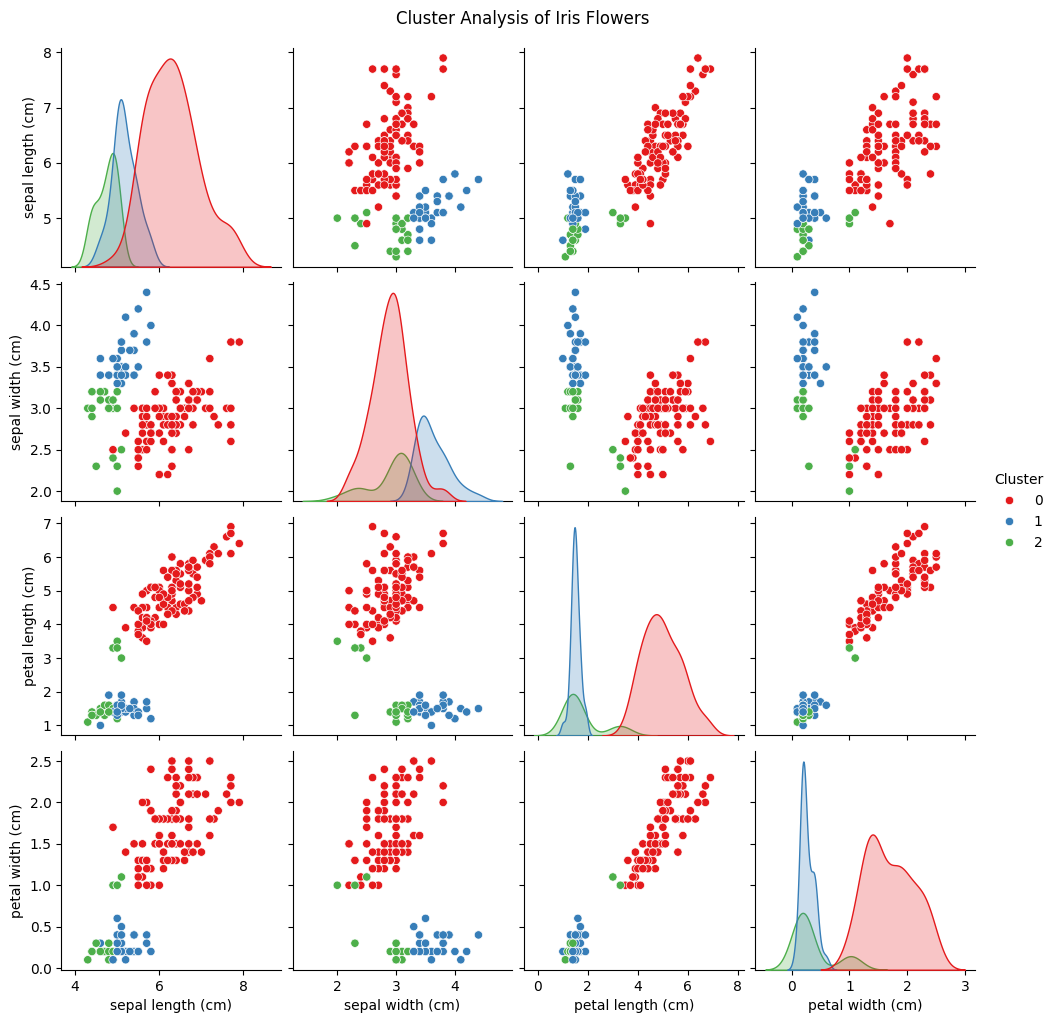

In [1]:
# ============================================
# Cluster Analysis Example: Iris Dataset
# ============================================

# --------------------------------------------
# Step 1: Import required libraries
# --------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# --------------------------------------------
# Step 2: Load the dataset
# --------------------------------------------
iris = load_iris()

# Features (independent variables)
X = iris.data

# Convert to DataFrame for easier handling
df = pd.DataFrame(X, columns=iris.feature_names)

print("First five observations:")
print(df.head())

# --------------------------------------------
# Step 3: Standardize the data
# --------------------------------------------
# Important: K-means is sensitive to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------
# Step 4: Determine optimal number of clusters (Elbow Method)
# --------------------------------------------
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=7)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow curve
plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

# --------------------------------------------
# Step 5: Fit K-means with chosen number of clusters
# --------------------------------------------
# From the elbow plot, we typically choose k = 3
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_scaled)

# Predicted cluster labels
cluster_labels = kmeans.labels_

# --------------------------------------------
# Step 6: Evaluate clustering performance
# --------------------------------------------
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"\nSilhouette Score for {optimal_k} clusters: {sil_score:.4f}")

# --------------------------------------------
# Step 7: Add cluster labels to dataset
# --------------------------------------------
df['Cluster'] = cluster_labels

print("\nFirst few rows with cluster assignments:")
print(df.head())

# --------------------------------------------
# Step 8: Visualize clusters
# --------------------------------------------
sns.pairplot(df, hue='Cluster', palette='Set1')
plt.suptitle('Cluster Analysis of Iris Flowers', y=1.02)
plt.show()
